<a href="https://colab.research.google.com/github/caaiopaivaa/CNN_silvafilho2022/blob/main/CNN_silvafilho2022_V_F.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install tensorflow torchvision scikit-learn matplotlib numpy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.9/572.9 MB 818.3 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 126.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 78.0 MB/s eta 0:00:00
  Attempting uninstall: h5py
    Found existing installation: h5py 3.16.0
    Uninstalling h5py-3.16.0:
      Successfully uninstalled h5py-3.16.0


In [2]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from torchvision.datasets import EMNIST
import matplotlib.pyplot as plt

/usr/local/lib/python3.13/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


In [3]:
# 1. Reprodutibilidade e Hardware
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

gpus = tf.config.list_physical_devices('GPU')
print("Dispositivo ativo:", gpus[0] if gpus else "CPU")

# 2. Download bruto do EMNIST Balanced via Torchvision
print("\nBaixando dados do EMNIST...")
raw_train = EMNIST(root='./data', split='balanced', train=True, download=True)
raw_test = EMNIST(root='./data', split='balanced', train=False, download=True)

Dispositivo ativo: CPU

Baixando dados do EMNIST...


100%|██████████| 562M/562M [00:02<00:00, 191MB/s]


In [4]:

X_raw = np.concatenate([raw_train.data.numpy(), raw_test.data.numpy()], axis=0)
y_raw = np.concatenate([raw_train.targets.numpy(), raw_test.targets.numpy()], axis=0)

# Expansão para formato matricial (N, H, W, 1) e correção da transposição
X_raw = np.expand_dims(X_raw, axis=-1)
X_raw = np.transpose(X_raw, (0, 2, 1, 3))

# 3. Filtragem das Letras 'V' e 'F'
# No EMNIST Balanced:
# - 'V' (maiúsculo e minúsculo) já vem fundido sob o código 31.
# - 'F' maiúsculo é o código 15; 'f' minúsculo possui código próprio 40.
INCLUDE_LOWERCASE = True

target_map = {
    31: 0,  # 'V' / 'v' -> Classe 0
    15: 1,  # 'F'       -> Classe 1
}

if INCLUDE_LOWERCASE:
    target_map[40] = 1  # 'f' -> Classe 1

mask = np.isin(y_raw, list(target_map.keys()))
X_filtered = X_raw[mask]
y_filtered = np.array([target_map[val] for val in y_raw[mask]])

CLASS_NAMES = ['V', 'F']
NUM_CLASSES = len(CLASS_NAMES)
print(f"Total de amostras selecionadas ('V' e 'F'): {X_filtered.shape[0]}")

# 4. Divisão Estratificada: 70% Treino | 15% Validação | 15% Teste
X_train, X_temp, y_train, y_temp = train_test_split(
    X_filtered, y_filtered, test_size=0.30, random_state=SEED, stratify=y_filtered
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=SEED, stratify=y_temp
)

print(f"Treino (70%):     {X_train.shape[0]} amostras")
print(f"Validação (15%):  {X_val.shape[0]} amostras")
print(f"Teste (15%):      {X_test.shape[0]} amostras")

# 5. Pipeline de Dados: Formato (32, 32, 3) e Normalização [0, 1]
def preprocess(image, label):
    image = tf.cast(image, tf.float32) / 255.0
    image = tf.image.resize(image, [32, 32])
    image = tf.image.grayscale_to_rgb(image)
    return image, label

BATCH_SIZE = 128
AUTOTUNE = tf.data.AUTOTUNE

def create_dataset(X, y, shuffle=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    if shuffle:
        ds = ds.shuffle(buffer_size=5000, seed=SEED)
    return ds.batch(BATCH_SIZE).prefetch(buffer_size=AUTOTUNE)

train_ds = create_dataset(X_train, y_train, shuffle=True)
val_ds = create_dataset(X_val, y_val)
test_ds = create_dataset(X_test, y_test)

Total de amostras selecionadas ('V' e 'F'): 8400
Treino (70%):     5880 amostras
Validação (15%):  1260 amostras
Teste (15%):      1260 amostras


In [5]:
# 6. Nova Arquitetura CNN: 1 Conv(32) + 2 Conv(64) + MaxPool(2x2) + Flatten
model = models.Sequential([
    layers.Input(shape=(32, 32, 3)),

    # 1 Camada Convolucional com 32 filtros (3x3), ReLU
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu', padding='same'),

    # 2 Camadas Convolucionais com 64 filtros (3x3), ReLU
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu', padding='same'),

    # Camada de Max Pooling (2x2)
    layers.MaxPooling2D(pool_size=(2, 2)),

    # Camada Flatten
    layers.Flatten(),

    # Camada de Saída com Softmax (2 classes: V e F)
    layers.Dense(NUM_CLASSES, activation='softmax')
])

# 7. Compilação com Otimizador Adam
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# 8. Treinamento
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=3,
        restore_best_weights=True,
        verbose=1
    )
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=callbacks
)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 16384)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 2)              │        32,770 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 89,090 (348.01 KB)

 Trainable params: 89,090 (348.01 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 452ms/step - accuracy: 0.9549 - loss: 0.1190 - val_accuracy: 0.9905 - val_loss: 0.0315
Epoch 2/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 451ms/step - accuracy: 0.9937 - loss: 0.0195 - val_accuracy: 0.9929 - val_loss: 0.0254
Epoch 3/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 453ms/step - accuracy: 0.9971 - loss: 0.0093 - val_accuracy: 0.9968 - val_loss: 0.0125
Epoch 4/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 449ms/step - accuracy: 0.9976 - loss: 0.0061 - val_accuracy: 0.9944 - val_loss: 0.0165
Epoch 5/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 452ms/step - accuracy: 0.9988 - loss: 0.0035 - val_accuracy: 0.9944 - val_loss: 0.0207
Epoch 6/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 451ms/step - accuracy: 0.9990 - loss: 0.0040 - val_accuracy: 0.9976 - val_loss: 0.0056
Epoch 7/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 451ms/step - accuracy: 0.9997 - loss: 0.0020 - val_accuracy: 0.9952 - val_loss: 0.0145
Epoch 8/15
46/46 ━━━━━━━━━━━━━━━━━━━━ 21s 452ms/step - accuracy: 0.9998 - loss: 0.0010 - val_accu

In [6]:
# 9. Avaliação no Conjunto de Teste Independente (15%)
test_loss, test_acc = model.evaluate(test_ds, verbose=1)
print(f"\n=======================================================")
print(f"Resultado Final no Teste ('V' vs 'F'):")
print(f"Loss: {test_loss:.4f} | Acurácia: {test_acc * 100:.2f}%")
print(f"=======================================================")

10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9952 - loss: 0.0141 

Resultado Final no Teste ('V' vs 'F'):
Loss: 0.0141 | Acurácia: 99.52%


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


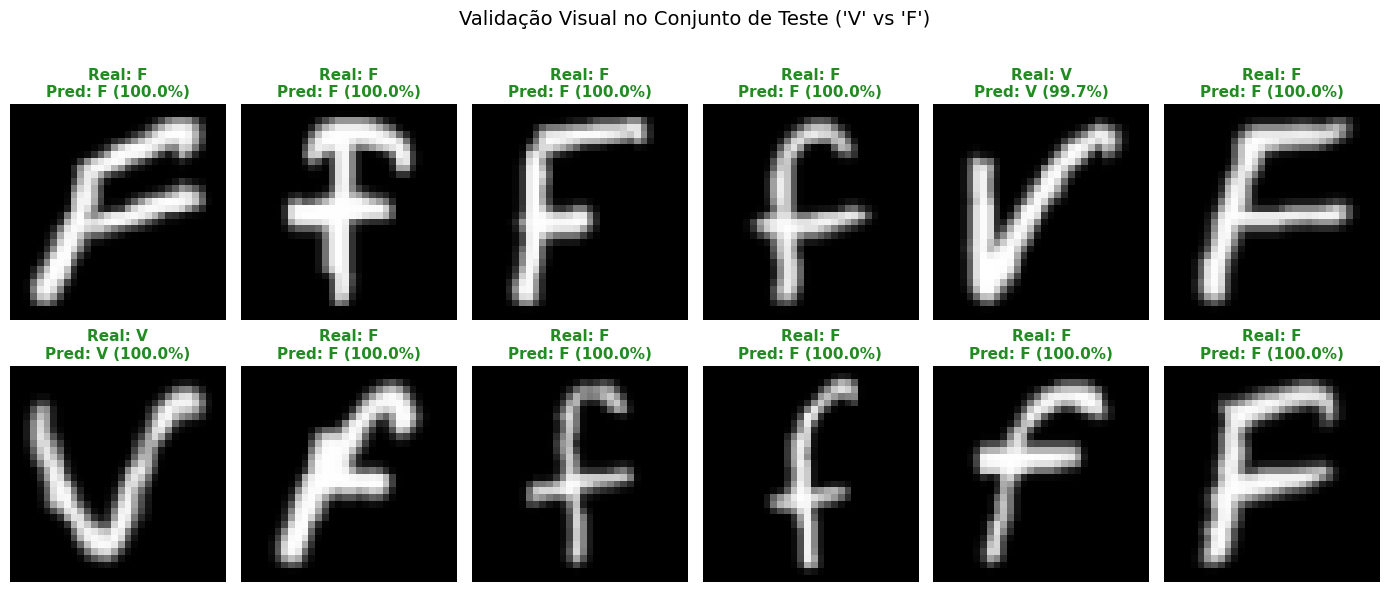

In [7]:
import numpy as np
import matplotlib.pyplot as plt

# Garante a definição das classes
CLASS_NAMES = ['V', 'F']

# 1. Coleta um lote de teste para inferência
images_batch, labels_batch = next(iter(test_ds))
predictions = model.predict(images_batch)
pred_labels = np.argmax(predictions, axis=1)

# 2. Plota 12 amostras com Real vs Predito e % de Confiança
plt.figure(figsize=(14, 6))

for i in range(12):
    plt.subplot(2, 6, i + 1)

    # Exibe a imagem (32x32x3 já normalizada entre [0, 1])
    plt.imshow(images_batch[i].numpy())

    true_char = CLASS_NAMES[labels_batch[i]]
    pred_char = CLASS_NAMES[pred_labels[i]]
    confidence = predictions[i][pred_labels[i]] * 100

    # Verde para acerto, Vermelho para erro
    color = 'forestgreen' if true_char == pred_char else 'firebrick'

    plt.title(
        f"Real: {true_char}\nPred: {pred_char} ({confidence:.1f}%)",
        color=color,
        fontsize=11,
        fontweight='bold'
    )
    plt.axis('off')

plt.suptitle("Validação Visual no Conjunto de Teste ('V' vs 'F')", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()